# Feature engineering

In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold

from heart_failure.config.config import (
    INTERIM_DATA_DIR, PROCESSED_DATA_DIR, HEART_DISEASE, SEX
)
from heart_failure.dataset import split_data
from heart_failure.config.features import RANDOM_STATE, TE_CV, TARGET_CORR_THRESHOLD
from heart_failure.features import select_by_vif, get_fe_pipeline
from heart_failure.plots import plot_corr_matrix, kdeplot_features_by_target

2026-06-25 14:07:19.045 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

### Feature implementing

In [3]:
cv = StratifiedKFold(n_splits=TE_CV, shuffle=True, random_state=RANDOM_STATE)
fe_pipeline = get_fe_pipeline(cv)

In [4]:
X_train = fe_pipeline.fit_transform(X_train, y_train)
X_test = fe_pipeline.transform(X_test)

In [5]:
X_train.head()

,target_encoder__RestingECG,target_encoder__ChestPainType,target_encoder__ST_Slope,binarizer__Age,binarizer__Cholesterol,binarizer__MaxHR,binary_encoder__Sex,binary_encoder__FastingBS,binary_encoder__ExerciseAngina,remainder__RestingBP,remainder__Oldpeak,remainder__Age_MaxHR_ratio,remainder__conjunctive_rules,remainder__Oldpeak_ChestPainType_te,remainder__Oldpeak_Cholesterol_ST_Slope_te,remainder__MaxHR_RestingECG_te,remainder__Age_Cholesterol_Sex_te,remainder__FastingBS_ST_Slope_te,remainder__FastingBS_ChestPainType_te,remainder__FastingBS_ExerciseAngina_te
839,0.518974,0.158438,0.847055,1.0,1.0,4.0,1.0,0.0,0.0,135.0,0.0,0.310606,1,0.081867,0.792238,0.618826,0.426938,0.805747,0.121224,0.250968
351,0.638348,0.782036,0.182399,1.0,5.0,5.0,1.0,0.0,1.0,140.0,0.5,0.307143,1,0.833492,0.611060,0.542095,0.661229,0.130530,0.698837,0.834543
398,0.526223,0.805471,0.193831,4.0,4.0,3.0,1.0,1.0,1.0,165.0,1.0,0.426230,1,0.843779,0.596987,0.599322,0.780132,0.415644,0.958592,0.921032
563,0.626761,0.790451,0.845560,6.0,7.0,8.0,1.0,1.0,1.0,144.0,2.0,0.356250,1,0.933698,0.912481,0.267969,0.658700,0.974480,0.937159,0.926778
190,0.626761,0.790451,0.172154,2.0,8.0,2.0,1.0,0.0,0.0,180.0,0.0,0.383333,0,0.584768,0.112236,0.663341,1.000000,0.139357,0.726525,0.245693


In [6]:
X_train.isna().sum().sort_values(ascending=False).head()

target_encoder__RestingECG       0
target_encoder__ChestPainType    0
target_encoder__ST_Slope         0
binarizer__Age                   0
binarizer__Cholesterol           0
dtype: int64

In [7]:
X_test.isna().sum().sort_values(ascending=False).head()

target_encoder__RestingECG       0
target_encoder__ChestPainType    0
target_encoder__ST_Slope         0
binarizer__Age                   0
binarizer__Cholesterol           0
dtype: int64

### Feature correlation

In [8]:
train = X_train.merge(y_train, left_index=True, right_index=True)
corr_df = train.corr()

In [12]:
plot_corr_matrix(corr_df, width=800, height=800, fontsize=9)

Multicollinearity is present. When we calculate gender target encoding (ex.) into bins of some other feature, the probability of class 1 appearing can be repeated across splits by different features. Therefore, they are highly correlated with each other.

The features ChestPainType (te) and FastingBS_ChestPainType (te); ST_Slope (te) and FastingBS_ST_Slope are also highly correlated. This is explained by the fact that FastingBS is not a significant indicator of the disease, but simply represents the age group most susceptible to the disease.

In [13]:
low_correlated = corr_df[corr_df[HEART_DISEASE].abs() < TARGET_CORR_THRESHOLD].index.to_list()
low_correlated

['target_encoder__RestingECG',
 'binarizer__Cholesterol',
 'remainder__RestingBP']

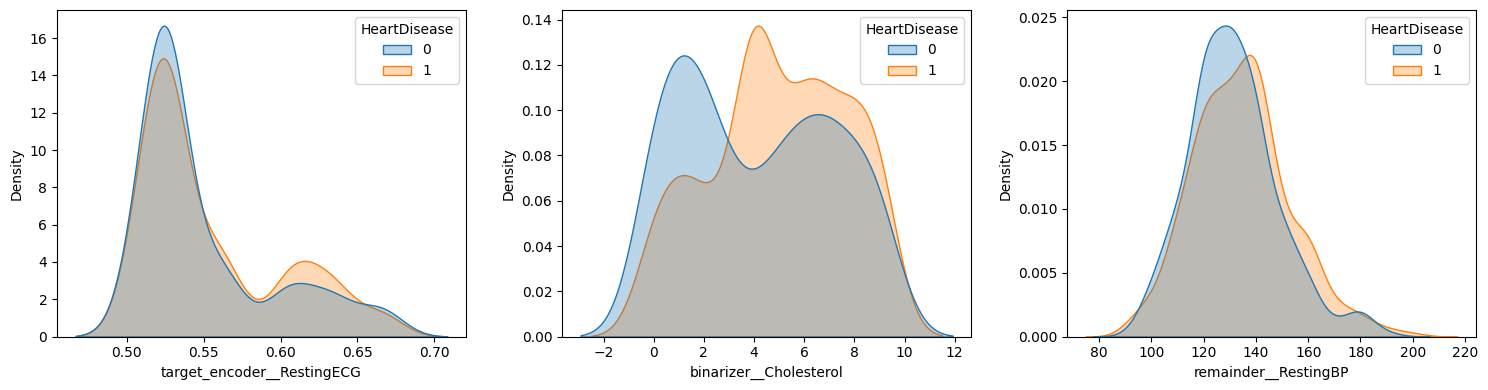

In [14]:
kdeplot_features_by_target(train, low_correlated, HEART_DISEASE)

For RestingECG, the correlation was expected to be small (the percentages initially didn't vary much across categories). RestingBP, in its original form, had no effect, so everything is clear here.

The cholesterol z-score was indeed unsuccessful. However, with binning, the class distributions clearly differ, but not so much as to create a significant correlation. This feature can be retained.

In [15]:
low_correlated.remove('binarizer__Cholesterol')
X_train = X_train.drop(columns=low_correlated)
X_test = X_test.drop(columns=low_correlated)

In [16]:
remaining_cols, drop_order = select_by_vif(X_train, y_train)
drop_order

remainder__FastingBS_ChestPainType_te     969.561204
remainder__FastingBS_ST_Slope_te          273.566077
remainder__FastingBS_ExerciseAngina_te     73.458758
remainder__Age_MaxHR_ratio                 59.735371
remainder__Oldpeak_ChestPainType_te        44.651119
target_encoder__ST_Slope                   27.706631
remainder__Age_Cholesterol_Sex_te          13.691348
remainder__MaxHR_RestingECG_te             10.068363
dtype: float64

In [17]:
remaining_cols

['target_encoder__ChestPainType',
 'binarizer__Age',
 'binarizer__Cholesterol',
 'binarizer__MaxHR',
 'binary_encoder__Sex',
 'binary_encoder__FastingBS',
 'binary_encoder__ExerciseAngina',
 'remainder__Oldpeak',
 'remainder__conjunctive_rules',
 'remainder__Oldpeak_Cholesterol_ST_Slope_te']

All intergroup features are discarded as duplicate signals. Only the transformed initial features and conjunctive rules remain.

In [19]:
train = X_train[remaining_cols].merge(y_train, left_index=True, right_index=True)
corr_df = train.corr()
plot_corr_matrix(corr_df, width=600, height=600, fontsize=9)

In [20]:
pd.Series(remaining_cols).to_csv(PROCESSED_DATA_DIR / 'remaining_cols.csv', index=False)

### Binned features

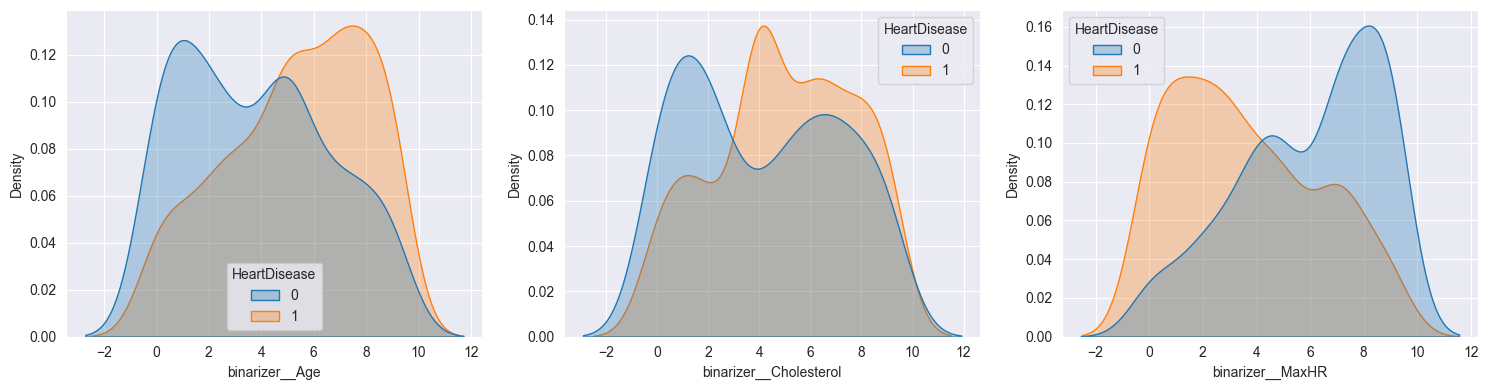

In [40]:
binned = X_train.columns[X_train.columns.str.startswith("binarizer__")]
kdeplot_features_by_target(train, binned, HEART_DISEASE)

Target correlation with binned features has increased. Class distributions do not overlap. Binning definitely helps for cholesterol, which has abnormally high values. Age and MaxHR also have rare high/low values. This helps at least linear models.